In [10]:
import numpy as np
import pandas as pd
import uproot
from glob import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import xgboost as xgb

In [14]:
# 60 runs logarithmically spaced in momentum from 0.5 to 10 GeV/c
N_RUNS = 80
N_GEN  = 1000  # events generated per run

MOMENTA_GEV = np.logspace(np.log10(0.5), np.log10(10.0), N_RUNS)
print("Momenta (GeV/c):")
print(np.round(MOMENTA_GEV, 4))

Momenta (GeV/c):
[ 0.5     0.5193  0.5394  0.5602  0.5819  0.6044  0.6277  0.652   0.6772
  0.7034  0.7306  0.7588  0.7881  0.8186  0.8502  0.8831  0.9172  0.9527
  0.9895  1.0277  1.0674  1.1087  1.1515  1.1961  1.2423  1.2903  1.3402
  1.392   1.4458  1.5016  1.5597  1.6199  1.6826  1.7476  1.8151  1.8853
  1.9581  2.0338  2.1124  2.1941  2.2789  2.3669  2.4584  2.5534  2.6521
  2.7546  2.8611  2.9717  3.0865  3.2058  3.3297  3.4584  3.5921  3.7309
  3.8751  4.0249  4.1804  4.342   4.5098  4.6841  4.8651  5.0532  5.2485
  5.4513  5.662   5.8808  6.1081  6.3442  6.5894  6.844   7.1086  7.3833
  7.6686  7.965   8.2729  8.5926  8.9247  9.2696  9.6279 10.    ]


In [15]:
BRANCHES = ['fEvent', 'fEdep', 'fdEdx', 'Ekin', 'TOF', 'TrackLength', 'ScatteringAng', 'Momentum']

def load_hits_with_efficiency(pattern, n_generated=N_GEN):
    """
    Load all ROOT files matching pattern.
    Returns:
        hits_df  : DataFrame with all step-level hits + run_id column
        eff_df   : DataFrame with run_id, n_detected, efficiency per run
    """
    files = sorted(glob(pattern))
    dfs, eff_records = [], []

    for run_id, path in enumerate(files):
        with uproot.open(path) as f:
            best_key = max(f.keys(), key=lambda k: f[k].num_entries)
            tree = f[best_key]
            if tree.num_entries == 0:
                eff_records.append({'run_id': run_id, 'n_detected': 0, 'efficiency': 0.0})
                continue
            data = {b: tree[b].array(library='np') for b in BRANCHES}
            df = pd.DataFrame(data)
            df['run_id'] = run_id

        n_detected = df['fEvent'].nunique()
        eff_records.append({
            'run_id': run_id,
            'n_detected': n_detected,
            'efficiency': n_detected / n_generated
        })
        dfs.append(df)

    hits_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=BRANCHES + ['run_id'])
    eff_df  = pd.DataFrame(eff_records)
    return hits_df, eff_df


hits_mu, eff_mu = load_hits_with_efficiency('data/muon/output_run*.root')
hits_pi, eff_pi = load_hits_with_efficiency('data/pion/output_run*.root')

print(f"Muon  hits : {len(hits_mu):>10,}  |  runs with signal: {(eff_mu['n_detected']>0).sum()}/{N_RUNS}")
print(f"Pion  hits : {len(hits_pi):>10,}  |  runs with signal: {(eff_pi['n_detected']>0).sum()}/{N_RUNS}")

Muon  hits :    253,931  |  runs with signal: 62/80
Pion  hits :    167,958  |  runs with signal: 61/80


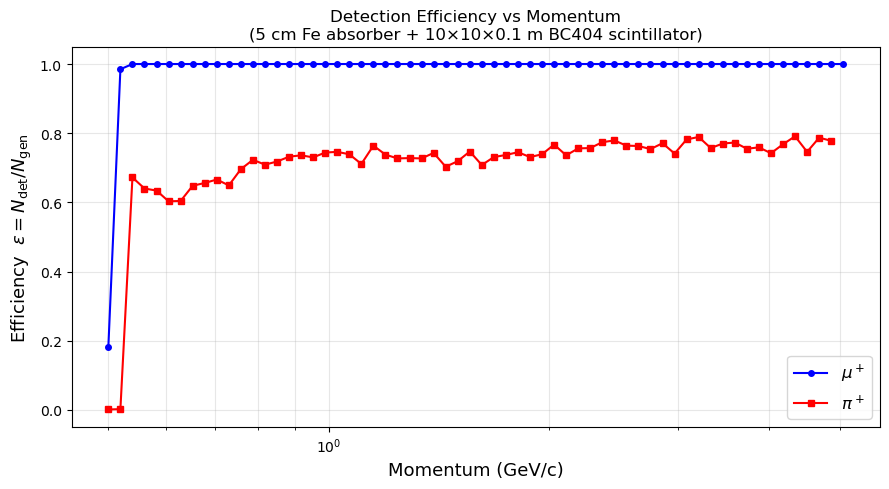

Saved: efficiency_curve.png


In [16]:
# Attach momentum to each run
eff_mu['momentum'] = MOMENTA_GEV[:len(eff_mu)]
eff_pi['momentum'] = MOMENTA_GEV[:len(eff_pi)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(eff_mu['momentum'], eff_mu['efficiency'], 'b-o', markersize=4, label=r'$\mu^+$')
ax.plot(eff_pi['momentum'], eff_pi['efficiency'], 'r-s', markersize=4, label=r'$\pi^+$')
ax.set_xlabel('Momentum (GeV/c)', fontsize=13)
ax.set_ylabel(r'Efficiency  $\varepsilon = N_{\mathrm{det}} / N_{\mathrm{gen}}$', fontsize=13)
ax.set_title('Detection Efficiency vs Momentum\n(5 cm Fe absorber + 10×10×0.1 m BC404 scintillator)', fontsize=12)
ax.legend(fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('../Pion and muon simulation/img/efficiency_curve.png', dpi=150)
plt.show()
print("Saved: efficiency_curve.png")

In [17]:
def aggregate_events(hits_df, label):
    """
    Aggregate step-level hits into one row per event.

    Geometry note: fX, fY, fZ are the detector VOLUME CENTER (0, 0, 1.10 m)
    — constant for every hit, so they carry no information and are excluded.
    Features are built from energy deposition, kinematics, TOF, and scattering.
    """
    hits_df = hits_df.copy()
    hits_df['event_uid'] = hits_df['run_id'].astype(str) + '_' + hits_df['fEvent'].astype(int).astype(str)

    g = hits_df.groupby('event_uid')

    feats = pd.DataFrame({
        # Number of tracking steps inside the scintillator
        'n_steps'        : g['fEdep'].count(),

        # Energy deposition
        'edep_total'     : g['fEdep'].sum(),
        'edep_mean'      : g['fEdep'].mean(),
        'edep_max'       : g['fEdep'].max(),
        'edep_std'       : g['fEdep'].std().fillna(0),

        # dE/dx  — main Bethe-Bloch discriminator
        'dedx_mean'      : g['fdEdx'].mean(),
        'dedx_max'       : g['fdEdx'].max(),
        'dedx_std'       : g['fdEdx'].std().fillna(0),

        # Kinetic energy at entry/exit of scintillator
        'ekin_entry'     : g['Ekin'].first(),
        'ekin_exit'      : g['Ekin'].last(),
        'ekin_loss'      : g['Ekin'].first() - g['Ekin'].last(),

        # Time of flight (mass-dependent velocity → arrival time)
        'tof_entry'      : g['TOF'].first(),
        'tof_exit'       : g['TOF'].last(),
        'tof_range'      : g['TOF'].max() - g['TOF'].min(),

        # Track length (cumulative from gun to scintillator)
        'track_entry'    : g['TrackLength'].first(),
        'track_exit'     : g['TrackLength'].last(),
        'track_in_scint' : g['TrackLength'].last() - g['TrackLength'].first(),

        # Scattering angle inside scintillator
        'scat_mean'      : g['ScatteringAng'].mean(),
        'scat_max'       : g['ScatteringAng'].max(),
        'scat_sum'       : g['ScatteringAng'].sum(),

        # Momentum magnitude at entry and exit
        'momentum_entry' : g['Momentum'].first(),
        'momentum_exit'  : g['Momentum'].last(),
        'momentum_loss'  : g['Momentum'].first() - g['Momentum'].last(),
    })

    feats['run_id'] = hits_df.groupby('event_uid')['run_id'].first()
    feats['label']  = label
    return feats.reset_index()


events_mu = aggregate_events(hits_mu, label=1)
events_pi = aggregate_events(hits_pi, label=0)

print(f"Muon  events: {len(events_mu):,}")
print(f"Pion  events: {len(events_pi):,}")

Muon  events: 61,167
Pion  events: 43,105


In [18]:
# Balance to 50k:50k (or the smaller class size if < 50k)
N_PER_CLASS = min(50_000, len(events_mu), len(events_pi))
print(f"Using {N_PER_CLASS:,} events per class")

events_mu_bal = events_mu.sample(N_PER_CLASS, random_state=42)
events_pi_bal = events_pi.sample(N_PER_CLASS, random_state=42)

df = pd.concat([events_mu_bal, events_pi_bal], ignore_index=True).sample(frac=1, random_state=42)

print(f"\nTotal dataset: {len(df):,} events")
print(df['label'].value_counts().rename({1: 'muon (1)', 0: 'pion (0)'}))

Using 43,105 events per class

Total dataset: 86,210 events
label
muon (1)    43105
pion (0)    43105
Name: count, dtype: int64


In [19]:
FEATURES = [c for c in df.columns if c not in ('event_uid', 'label', 'run_id')]

X = df[FEATURES]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

Train: (68968, 23)   Test: (17242, 23)
[0]	validation_0-logloss:0.68346
[50]	validation_0-logloss:0.46674
[100]	validation_0-logloss:0.28219
[150]	validation_0-logloss:0.15475
[200]	validation_0-logloss:0.09561
[250]	validation_0-logloss:0.06482
[300]	validation_0-logloss:0.04227
[350]	validation_0-logloss:0.02927
[399]	validation_0-logloss:0.02057


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'logloss'


ROC-AUC: 1.0000

              precision    recall  f1-score   support

    pion (0)       1.00      1.00      1.00      8621
    muon (1)       1.00      1.00      1.00      8621

    accuracy                           1.00     17242
   macro avg       1.00      1.00      1.00     17242
weighted avg       1.00      1.00      1.00     17242



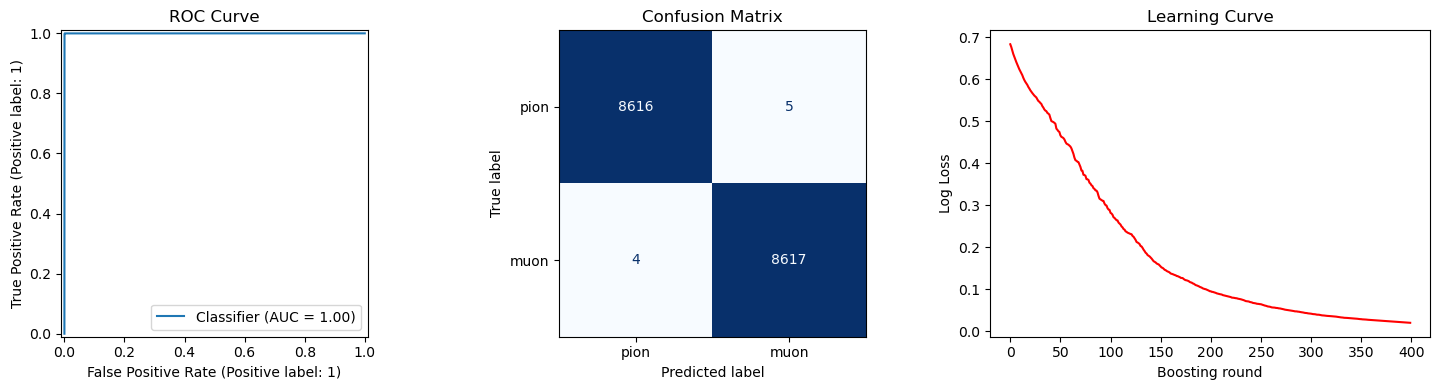

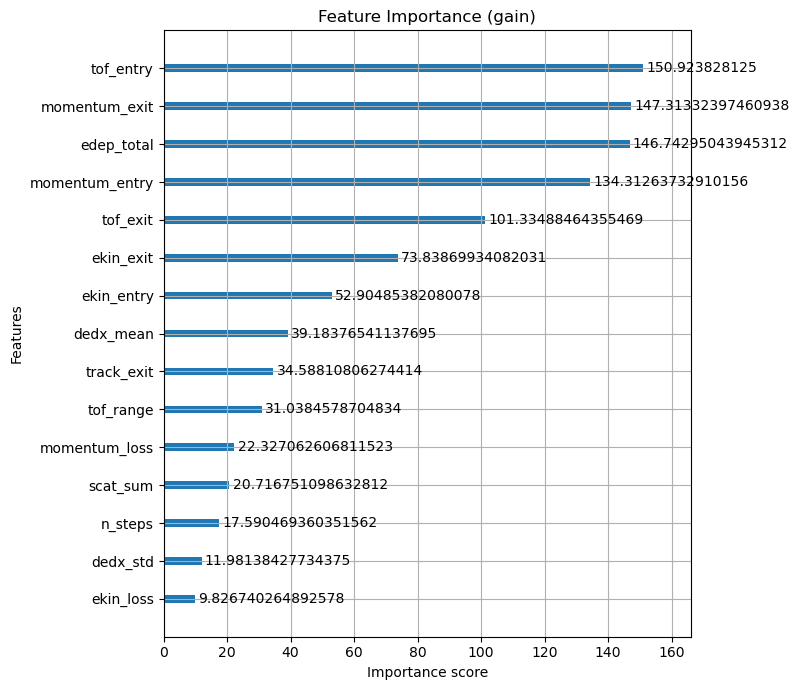

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['pion (0)', 'muon (1)']))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title('ROC Curve')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap='Blues', colorbar=False, ax=axes[1],
    display_labels=['pion', 'muon']
)
axes[1].set_title('Confusion Matrix')

axes[2].plot(model.evals_result()['validation_0']['logloss'], color='red')
axes[2].set_xlabel('Boosting round')
axes[2].set_ylabel('Log Loss')
axes[2].set_title('Learning Curve')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
xgb.plot_importance(model, importance_type='gain', ax=ax, max_num_features=15)
ax.set_title('Feature Importance (gain)')
plt.tight_layout()
plt.show()

Momentum range  N events  Error (%)  ROC-AUC
   0.5–1 GeV/c      4872       0.14      1.0
     1–2 GeV/c      5189       0.02      1.0
     2–4 GeV/c      5280       0.02      1.0
     4–7 GeV/c      1901       0.00      1.0


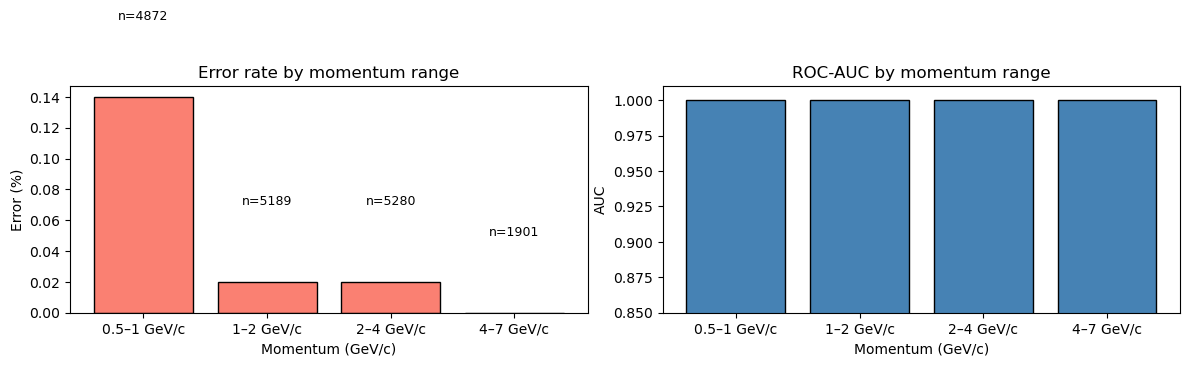

In [21]:
# Map run_id → momentum (GeV/c)
run_to_momentum = dict(enumerate(MOMENTA_GEV))

df_test = X_test.copy()
df_test['run_id']      = df.loc[X_test.index, 'run_id'].values
df_test['momentum_run'] = df_test['run_id'].map(run_to_momentum)
df_test['y_true']      = y_test.values
df_test['y_pred']      = y_pred
df_test['y_prob']      = y_prob

bins_p  = [0.4, 1.0, 2.0, 4.0, 7.0, 10.5]
labels_p = ['0.5–1 GeV/c', '1–2 GeV/c', '2–4 GeV/c', '4–7 GeV/c', '7–10 GeV/c']
df_test['p_bin'] = pd.cut(df_test['momentum_run'], bins=bins_p, labels=labels_p)

results = []
for bl in labels_p:
    sub = df_test[df_test['p_bin'] == bl]
    n = len(sub)
    if n == 0:
        continue
    err = (sub['y_true'] != sub['y_pred']).mean() * 100
    auc = roc_auc_score(sub['y_true'], sub['y_prob']) if sub['y_true'].nunique() == 2 else None
    results.append({
        'Momentum range': bl,
        'N events': n,
        'Error (%)': round(err, 2),
        'ROC-AUC': round(auc, 4) if auc else 'N/A'
    })

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_res['Momentum range'], df_res['Error (%)'], color='salmon', edgecolor='black')
axes[0].set_title('Error rate by momentum range')
axes[0].set_ylabel('Error (%)')
axes[0].set_xlabel('Momentum (GeV/c)')
for i, row in df_res.iterrows():
    axes[0].text(i, row['Error (%)'] + 0.05, f"n={row['N events']}", ha='center', fontsize=9)

aucs = [r['ROC-AUC'] if isinstance(r['ROC-AUC'], float) else 0 for _, r in df_res.iterrows()]
axes[1].bar(df_res['Momentum range'], aucs, color='steelblue', edgecolor='black')
axes[1].set_title('ROC-AUC by momentum range')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.85, 1.01)
axes[1].set_xlabel('Momentum (GeV/c)')

plt.tight_layout()
plt.show()